In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
path = "/content/gdrive/MyDrive/MachineLearning/Praktikum5"

In [ ]:
import pandas as pd
df = pd.read_csv(path + '/Data/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
#Cek missing value
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
# Cek duplicate
df.duplicated().sum()

np.int64(0)

In [ ]:
# Menghapus data duplikat
df = df.drop_duplicates()

In [ ]:
# Cek duplicate ulang setelah menghapus
df.duplicated().sum()

np.int64(0)

In [ ]:
# Menghapus kolom ID dikarenakan kurang relevan
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

In [ ]:
# Mengendcoding kolom species
df['Species'] = df['Species'].astype('category')
df['Species_code'] = df['Species'].cat.codes
print("Mapping kelas target:")
print(dict(enumerate(df['Species'].cat.categories)))

Mapping kelas target:
{0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}


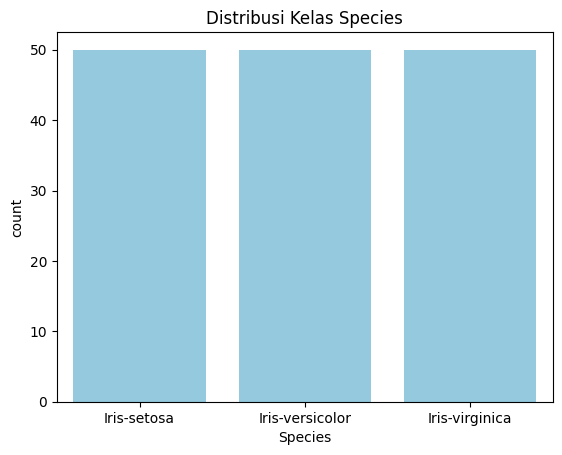

In [ ]:
sns.countplot(x='Species', data=df, color='skyblue')
plt.title('Distribusi Kelas Species')
plt.show()

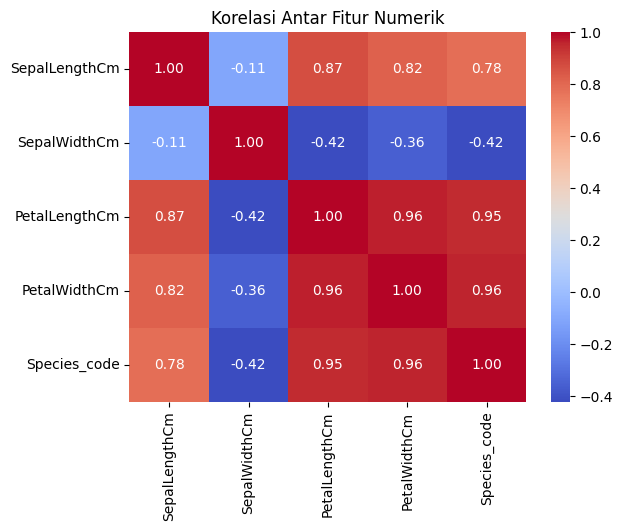

In [ ]:
sns.heatmap(df.drop(columns=['Species']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Antar Fitur Numerik')
plt.show()

In [ ]:
# Menentukan X (fitur) dan Y (target)
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species_code']

In [ ]:
# MemSplit data mennjadi 80% train dan 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah data train:", len(X_train))
print("Jumlah data test:", len(X_test))

Jumlah data train: 120
Jumlah data test: 30


In [ ]:
# Membuat Model Decision Tree
model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
# Mengevaluasi model
y_pred = model.predict(X_test)

print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=df['Species'].cat.categories))

Akurasi Model: 0.9333333333333333
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



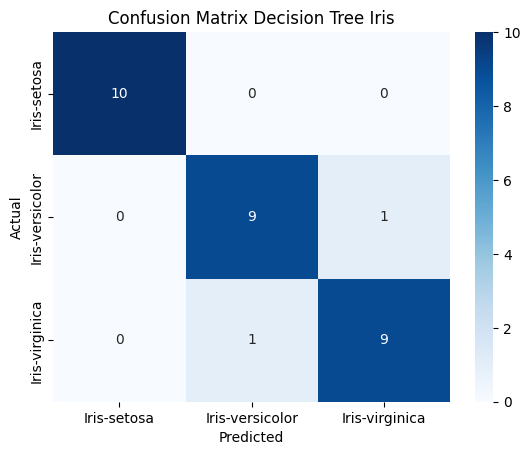

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=df['Species'].cat.categories,
            yticklabels=df['Species'].cat.categories)
plt.title("Confusion Matrix Decision Tree Iris")
plt.xlabel('Predicted')
plt.ylabel("Actual")
plt.show()

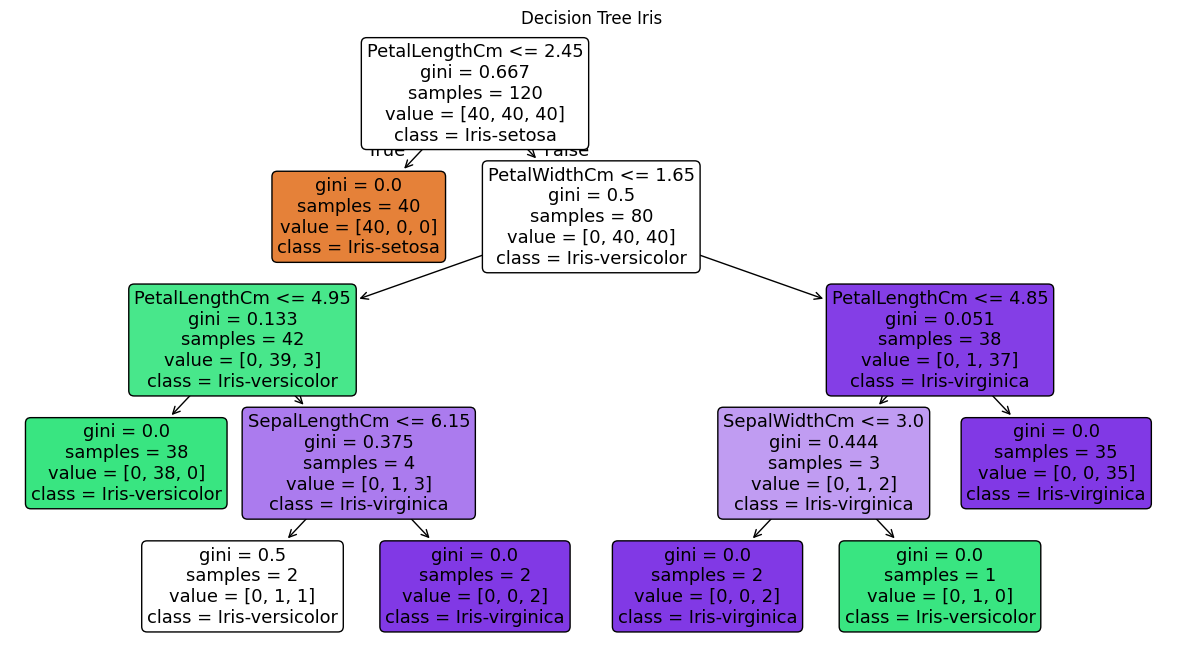

In [ ]:
# Memvisualisasi Struktur Decision Tree
plt.figure(figsize=(15,8))
plot_tree(model, feature_names=X.columns, class_names=df['Species'].cat.categories,
          filled=True, rounded=True)
plt.title("Decision Tree Iris")
plt.show()

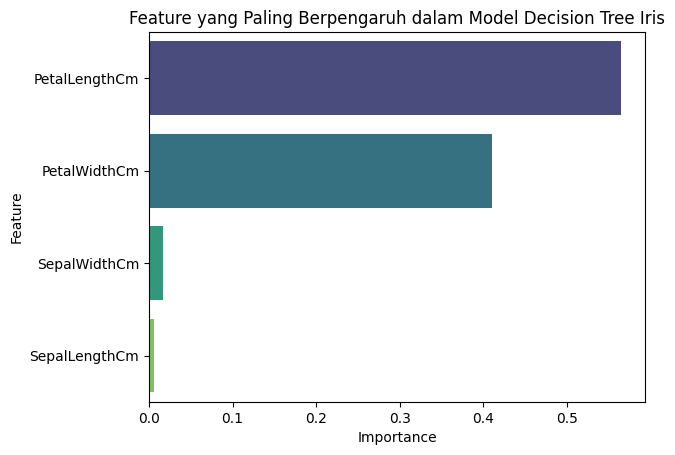

Feature Importance:
         Feature  Importance
2  PetalLengthCm    0.565639
3   PetalWidthCm    0.411154
1   SepalWidthCm    0.016878
0  SepalLengthCm    0.006329


In [ ]:
# Feature Importance (fitur yang paling berpengaruh)
sns.barplot(data=Importance, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title("Feature yang Paling Berpengaruh dalam Model Decision Tree Iris")
plt.show()


Importance = pd.DataFrame({
    'Feature': X.columns,'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(Importance)

In [ ]:
# Hyperparameter Tuning (Menentukan max_depth Terbaik)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

scores = {}
for d in range(2, 9):
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    scores[d] = accuracy_score(y_test, m.predict(X_test))

best_d = max(scores, key=scores.get)
print(f"Best max_depth: {best_d} | Acc: {round(scores[best_d]*100, 2)} %")

Best max_depth: 3 | Acc: 96.67 %
